In [1]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

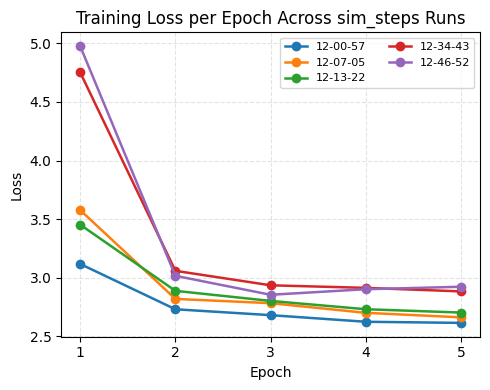

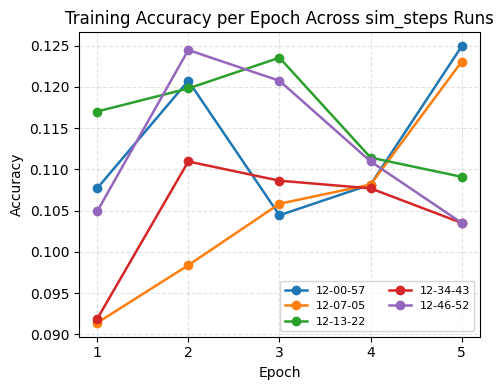

=== Best Metrics Across Files ===
Highest test accuracy: 0.153008 |  sim_steps: 20 |  file: var-sim_steps_2026-04-22_12-13-22_e-5_ctx-5_15.3.json
Lowest test loss: 2.674631 | sim_steps: 10 | file: var-sim_steps_2026-04-22_12-00-57_e-5_ctx-5_13.23.json


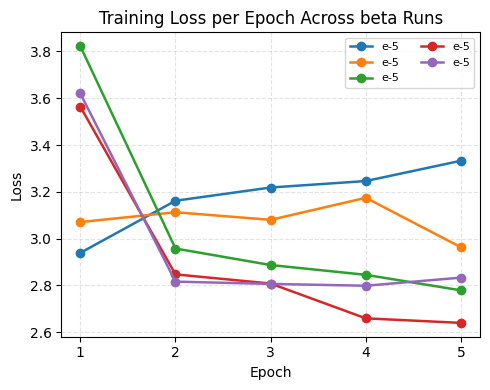

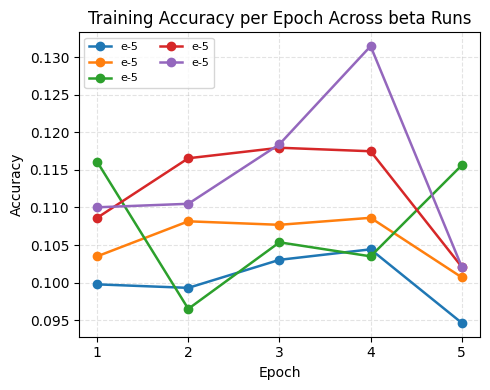

=== Best Metrics Across Files ===
Highest test accuracy: 0.110477 |  beta: 0.75 |  file: var-beta_2026-04-22_12-59-20_e-5_ctx-5_11.05.json
Lowest test loss: 2.722508 | beta: 0.95 | file: var-beta_2026-04-22_13-11-41_e-5_ctx-5_10.94.json


In [10]:
# Plot training loss and accuracy per epoch for each var-sim_steps result file

for condition in ['sim_steps', 'beta']:
    files = sorted(glob(f'../output_results/upos/var-{condition}_*.json'))
    if not files:
        raise FileNotFoundError(f'No matching files found in output_results/upos for condition: {condition}')

    best_accuracy = None
    best_accuracy_info = None
    lowest_loss = None
    lowest_loss_info = None
    max_loss_epoch_count = 0
    max_accuracy_epoch_count = 0

    plt.figure(figsize=(5, 4))
    for file in files:
        with open(file, 'r', encoding='utf-8') as f:
            data = json.load(f)

        training_config = data.get('training_config', {})
        results = data.get('results', {})
        sim_step = training_config.get('sim_steps', 'N/A')

        losses = results.get('epoch_train_loss', [])
        if losses:
            epochs = list(range(1, len(losses) + 1))
            max_loss_epoch_count = max(max_loss_epoch_count, len(losses))
            plt.plot(epochs, losses, marker='o', linewidth=1.8, label=Path(file).stem.split('_')[3])

        test_accuracy = results.get('test_accuracy')
        test_loss = results.get('test_loss')

        if test_accuracy is not None and (best_accuracy is None or test_accuracy > best_accuracy):
            best_accuracy = test_accuracy
            best_accuracy_info = {'file': Path(file).name, f'{condition}': training_config.get(condition, 'N/A')}

        if test_loss is not None and (lowest_loss is None or test_loss < lowest_loss):
            lowest_loss = test_loss
            lowest_loss_info = {'file': Path(file).name, f'{condition}': training_config.get(condition, 'N/A')}

    plt.title(f'Training Loss per Epoch Across {condition} Runs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    if max_loss_epoch_count > 0:
        plt.xticks(range(1, max_loss_epoch_count + 1))
    plt.grid(True, linestyle='--', alpha=0.35)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5, 4))
    for file in files:
        with open(file, 'r', encoding='utf-8') as f:
            data = json.load(f)

        results = data.get('results', {})
        accuracy_values = results.get('epoch_train_accuracy', [])
        if not accuracy_values:
            continue

        epochs = list(range(1, len(accuracy_values) + 1))
        max_accuracy_epoch_count = max(max_accuracy_epoch_count, len(accuracy_values))
        plt.plot(epochs, accuracy_values, marker='o', linewidth=1.8, label=Path(file).stem.split('_')[3])

    plt.title(f'Training Accuracy per Epoch Across {condition} Runs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    if max_accuracy_epoch_count > 0:
        plt.xticks(range(1, max_accuracy_epoch_count + 1))
    plt.grid(True, linestyle='--', alpha=0.35)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    print('=== Best Metrics Across Files ===')
    if best_accuracy_info is not None:
        print(
            f"Highest test accuracy: {best_accuracy:.6f} | ",
            f"{condition}: {best_accuracy_info[condition]} | ",
            f"file: {best_accuracy_info['file']}"
        )
    else:
        print('Highest test accuracy: not available')

    if lowest_loss_info is not None:
        print(
            f"Lowest test loss: {lowest_loss:.6f} | "
            f"{condition}: {lowest_loss_info[condition]} | "
            f"file: {lowest_loss_info['file']}"
        )
    else:
        print('Lowest test loss: not available')